# 6.4.- Modelos secuenciales: LSTM y Bidirectional LSTM

Las palabras de un texto no son independientes:  
su significado depende del **contexto anterior y posterior**.

Las **Redes Neuronales Recurrentes (RNN)** y sus variantes (LSTM, GRU)  
permiten procesar secuencias recordando información previa.

En este notebook aprenderás a:

1. Preparar texto para redes neuronales (tokenización y padding).  
2. Construir una red LSTM simple para análisis de sentimiento.  
3. Implementar una versión **Bidirectional LSTM**.  
4. Comparar resultados entre ambas arquitecturas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(33)

2025-10-26 10:50:16.478748: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-26 10:50:16.568154: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-26 10:50:17.687502: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Dataset de ejemplo

Usaremos un conjunto de frases positivas y negativas (similares al notebook anterior),
pero ahora las convertiremos en secuencias numéricas para poder procesarlas con una red neuronal.

In [2]:
data = {
    "texto": [
        # Positivas
        "La película fue excelente, me mantuvo enganchado de principio a fin y las actuaciones fueron brillantes.",
        "El restaurante es fantástico, la comida es deliciosa y el servicio impecable.",
        "Me encantó la atención al cliente, resolvieron mi problema en minutos y con mucha amabilidad.",
        "La experiencia fue maravillosa, sin duda volvería a repetir.",
        "Todo llegó en perfecto estado y antes del tiempo previsto, excelente compra.",
        "El hotel era cómodo, limpio y con un personal muy atento.",
        "El producto superó mis expectativas, la calidad es impresionante.",
        "Una serie muy bien escrita, con personajes que evolucionan y una historia atrapante.",
        "Muy satisfecho con el resultado, exactamente lo que esperaba.",
        "Un servicio rápido, eficiente y amable, recomendable al 100%.",

        # Negativas
        "La película fue aburrida, larga y con un final predecible.",
        "El servicio fue pésimo, la comida llegó fría y los camareros fueron groseros.",
        "El producto llegó dañado, con piezas rotas y nadie respondió mis mensajes.",
        "Fue una pérdida total de tiempo, no volveré a usar esta plataforma.",
        "La atención fue lenta y desorganizada, nada recomendable.",
        "El hotel estaba sucio, el baño olía mal y el aire acondicionado no funcionaba.",
        "Odio esta serie, los diálogos son forzados y la trama no tiene sentido.",
        "El envío tardó semanas y además el paquete llegó incompleto.",
        "El servicio técnico no solucionó nada, solo me hicieron perder tiempo.",
        "Una experiencia muy mala, no lo recomiendo a nadie."
    ],
    "sentimiento": [1]*10 + [0]*10
}

df = pd.DataFrame(data)
df.head()

,texto,sentimiento
0,"La película fue excelente, me mantuvo engancha...",1
1,"El restaurante es fantástico, la comida es del...",1
2,"Me encantó la atención al cliente, resolvieron...",1
3,"La experiencia fue maravillosa, sin duda volve...",1
4,Todo llegó en perfecto estado y antes del tiem...,1


## Preprocesamiento: tokenización y padding

Los modelos neuronales no trabajan con texto, sino con **secuencias de enteros**.

Pasos:
1. Tokenizar el texto con `Tokenizer` de Keras.  
2. Convertir las frases en secuencias numéricas.  
3. Igualar su longitud con `pad_sequences` (padding).

In [3]:
MAX_VOCAB = 2000      # tamaño máximo del vocabulario
MAX_LEN = 30          # longitud máxima de cada secuencia

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df["texto"])

# Convertir texto a secuencias
X = tokenizer.texts_to_sequences(df["texto"])
X_padded = pad_sequences(X, maxlen=MAX_LEN, padding='post', truncating='post')

y = np.array(df["sentimiento"])

print("Ejemplo de secuencia:", X_padded[0])
print("Tamaño del vocabulario:", len(tokenizer.word_index))
print("Forma de X_padded:", X_padded.shape)

Ejemplo de secuencia: [ 4 17  5 18 13 37 38 19 39  8 40  2 41 42 20 43  0  0  0  0  0  0  0  0
  0  0  0  0  0  0]
Tamaño del vocabulario: 138
Forma de X_padded: (20, 30)


## Modelo LSTM simple

La LSTM (Long Short-Term Memory) mejora las RNN tradicionales
gracias a sus *puertas* que permiten mantener o olvidar información.

La usaremos para clasificar frases como positivas o negativas.

In [5]:
# División de datos
X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=33, stratify=y)

# Definir modelo LSTM simple
model_lstm = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=64, input_length=MAX_LEN),
    LSTM(64),
    Dense(1, activation="sigmoid")
])

model_lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_lstm.summary()

# Entrenamiento
history_lstm = model_lstm.fit(X_train, y_train, epochs=10, batch_size=4, validation_split=0.2, verbose=0)

# Evaluación
y_pred = (model_lstm.predict(X_test) > 0.5).astype(int)
print("Accuracy LSTM:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación (LSTM):\n")
print(classification_report(y_test, y_pred, zero_division=0))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
W0000 00:00:1761475893.574368    3816 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Accuracy LSTM: 0.5

Reporte de clasificación (LSTM):

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.50      1.00      0.67         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



## Modelo Bidirectional LSTM

Una **Bidirectional LSTM** procesa la secuencia en ambas direcciones:
- De izquierda a derecha (orden natural)
- De derecha a izquierda (orden inverso)

Esto permite capturar contexto anterior y posterior a la vez.

In [7]:
model_bi = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=64, input_length=MAX_LEN),
    Bidirectional(LSTM(64)),
    Dense(1, activation="sigmoid")
])

model_bi.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_bi.summary()

# Entrenamiento
history_bi = model_bi.fit(X_train, y_train, epochs=10, batch_size=4, validation_split=0.2, verbose=0)

# Evaluación
y_pred_bi = (model_bi.predict(X_test) > 0.5).astype(int)
print("Accuracy Bidirectional LSTM:", accuracy_score(y_test, y_pred_bi))
print("\nReporte de clasificación (Bidirectional LSTM):\n")
print(classification_report(y_test, y_pred_bi, zero_division=0))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
Accuracy Bidirectional LSTM: 0.5

Reporte de clasificación (Bidirectional LSTM):

              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4



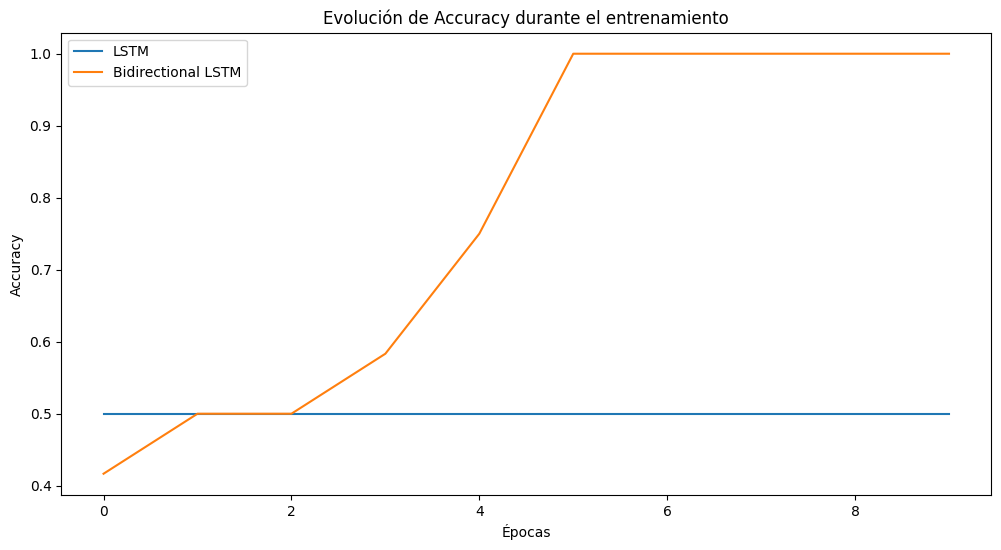

In [8]:
plt.plot(history_lstm.history["accuracy"], label="LSTM")
plt.plot(history_bi.history["accuracy"], label="Bidirectional LSTM")
plt.title("Evolución de Accuracy durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Ejercicio final

1. Aumenta el tamaño del vocabulario (`MAX_VOCAB`) o la longitud máxima (`MAX_LEN`) y observa cómo cambia el rendimiento.  
2. Añade una capa `Dropout(0.3)` para reducir sobreajuste.  
3. Experimenta con `Bidirectional(LSTM(128))` o más épocas de entrenamiento.  
4. Compara los resultados con los obtenidos usando BoW o TF–IDF.